Pipeline de visão computacional que extrai o contorno de uma imagem e envia as coordenadas para a tartaruga do turtlesim desenhar.

Todo o processamento é feito com numpy puro, sem bibliotecas de visão externas.

## Imports

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#importar imagem

imagem = cv2.imread('dog.jpg')


In [6]:
# mostrar ela pra ver se esta tudo certo
cv2.imshow('janela', imagem) 
cv2.waitKey(0)
cv2.destroyAllWindows()


QFontDatabase: Cannot find font directory /home/vboxuser/repositories/drawing-turtle/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/vboxuser/repositories/drawing-turtle/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/vboxuser/repositories/drawing-turtle/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/vboxuser/repositories/drawing-turtle/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for ex

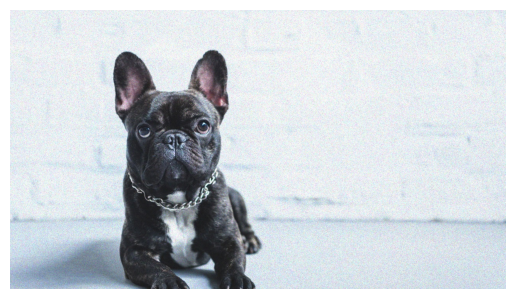

In [7]:
plt.axis('off')
plt.imshow(imagem[:, :, [2, 1, 0]])

In [8]:
imagem.shape

(720, 1280, 3)

In [9]:
# Preto e branco

# array da escala de cinza
escala_cinza = [0.114, 0.587, 0.299] 

preto_branco = np.dot(imagem, escala_cinza) # faz operacao de multiplicacao ponderada entre o array da imagem e o array da escala de cinza. 
# Multiplica cada componente BGR de cada pixel com os fatores de peso e soma tudo.
preto_branco = preto_branco.astype(np.uint8) # transforma o valor dos pixels pra 8bits (de novo) pro CV usar 




In [10]:
cv2.imshow('janela', preto_branco) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

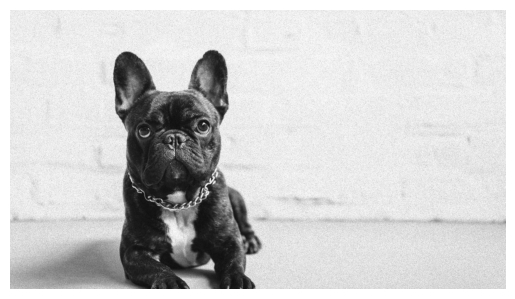

In [11]:
plt.axis('off')
plt.imshow(preto_branco, cmap='gray')

## Filtros

Blur gaussiano para suavizar a imagem antes da detecção de bordas, reduzindo ruído de alta frequência.

In [12]:
preto_branco.shape

(720, 1280)

In [13]:
# Blur #Talvez usar
kernel1 = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)



In [14]:
# Gaussiano 
 
# definir kernel para usarmos na convolucao
kernel2 = np.array([
    [ 1,  4,  7,  4, 1],
    [ 4, 16, 26, 16, 4],
    [ 7, 26, 41, 26, 7],
    [ 4, 16, 26, 16, 4],
    [ 1,  4,  7,  4, 1]
], dtype=np.float32)

# formula basica da convolucao
# (I * K)[x, y] = Σ_i Σ_j I[x + i, y + j] · K[i, j]
# I = Imagem, K = kernel

# Rotacionar o kernel (nesse caso nao eh necessario pq a matriz gaussiana eh simetrica)
# kernel2_flip = np.flipud(np.fliplr(kernel2))

img_h, img_w = preto_branco.shape
ker_h, ker_w = kernel2.shape

# Definir o tamanho e tipo da saida
gauss = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1),dtype=np.uint8)

for i in range(gauss.shape[0]):
    for j in range(gauss.shape[1]):
        # definindo a regiao de interesse 
        regiao = preto_branco[i:i+ker_h, j:j+ker_w]
        # multiplica e soma todos os pixels dentro da regiao pelo kernel
        gauss[i, j] = (np.sum(regiao * kernel2)/273).astype(np.uint8)


In [15]:
cv2.imshow('janela', gauss) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

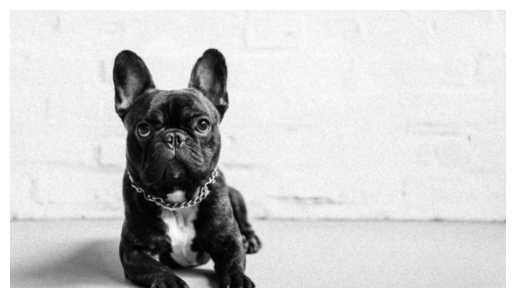

In [16]:
plt.axis('off')
plt.imshow(gauss, cmap='gray')

In [17]:
print(gauss)

[[236 235 235 ... 232 234 234]
 [238 236 235 ... 230 230 230]
 [235 234 233 ... 232 230 229]
 ...
 [189 191 191 ... 217 214 212]
 [186 186 189 ... 216 216 216]
 [187 187 190 ... 215 217 219]]


In [18]:
print(kernel2.sum())

273.0


In [19]:
# Sharpen (nitidez) # Talvez usar
kernel3 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

## Detecção de bordas

Operador Scharr nos eixos X e Y. O gradiente resultante é calculado como a magnitude do vetor formado pelos dois.

In [20]:
# Deteccao de borda

# Scharr X
kernel3 = np.array([
    [-3, 0, 3],
    [-10, 0, 10],
    [-3, 0, 3]
], dtype=np.float32)


img_h, img_w = gauss.shape
ker_h, ker_w = kernel3.shape

# Definir o tamanho e tipo da saida
scharrX = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))

for i in range(scharrX.shape[0]):
    for j in range(scharrX.shape[1]):
        # definindo a regiao de interesse 
        regiao = gauss[i:i+ker_h, j:j+ker_w]
        # multiplica e soma todos os pixels dentro da regiao pelo kernel. 
        scharrX[i, j] = (np.sum(regiao * kernel3))

# Normaliza 
scharrX = np.abs(scharrX)

# normaliza de novo para o maior valor 
scharrX = (scharrX/scharrX.max()*255)

# e converte para 8bits
scharrX_8bit = scharrX.astype(np.uint8)


In [21]:

cv2.imshow('janela', scharrX_8bit) 
cv2.waitKey(0)
cv2.destroyAllWindows()

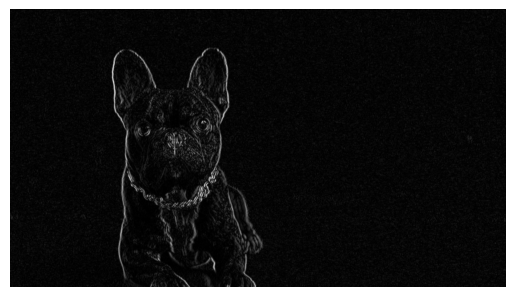

In [22]:
plt.axis('off')
plt.imshow(scharrX_8bit, cmap='gray')

In [23]:
#Scharr Y
kernel4 = np.array([
    [-3, -10, -3],
    [ 0,   0,  0],
    [ 3,  10,  3]
], dtype=np.float32)

img_h, img_w = gauss.shape
ker_h, ker_w = kernel4.shape

# Definir o tamanho e tipo da saida
scharrY = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))

for i in range(scharrY.shape[0]):
    for j in range(scharrY.shape[1]):
        # definindo a regiao de interesse 
        regiao = gauss[i:i+ker_h, j:j+ker_w]
        # multiplica e soma todos os pixels dentro da regiao pelo kernel. 
        scharrY[i, j] = (np.sum(regiao * kernel4))

#Normaliza pela soma absoluta do kernel
scharrY = np.abs(scharrY)

# normaliza de novo para o maior valor 
scharrY = (scharrY/scharrY.max()*255)

# e converte para 8bits
scharrY_8bit = scharrY.astype(np.uint8)

In [24]:
cv2.imshow('janela', scharrY_8bit) 
cv2.waitKey(0)
cv2.destroyAllWindows()

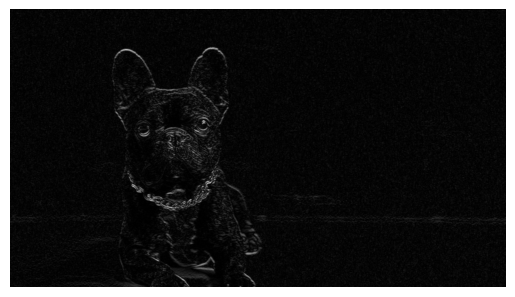

In [25]:
plt.axis('off')
plt.imshow(scharrY, cmap='gray')

In [26]:
# Junta os Scharrs

# calcula vetor resultante entre os dois scharrs
contorno = np.sqrt(scharrX**2+scharrY**2)

# normaliza
contorno = (contorno/contorno.max()*255).astype(np.uint8)


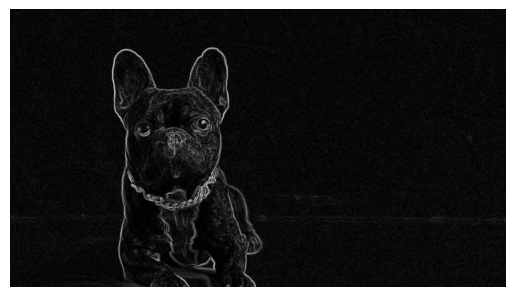

In [27]:
plt.axis('off')
plt.imshow(contorno, cmap='gray')

In [28]:
cv2.imshow('janela', contorno) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

# Remoção de ruído

Thresholding para binarizar a imagem, seguido de erosão para eliminar ruído pequeno.

## Thresholding

In [29]:
threshold = 60
binario = np.where(contorno < threshold, 0, 1)

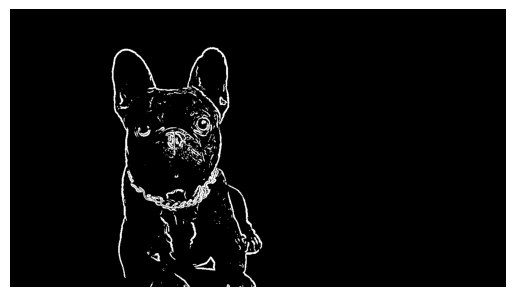

In [30]:
plt.axis('off')
plt.imshow(binario, cmap='gray')

## Erosão

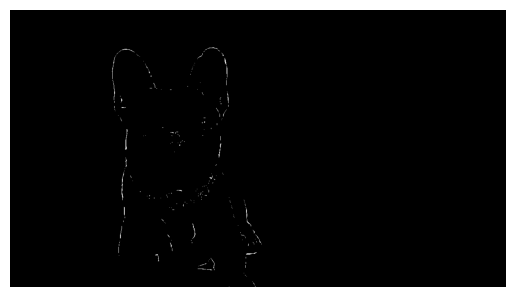

In [37]:
# Erosao
entrada = binario

aresta_k = 4
kernel5 = (np.ones((aresta_k, aresta_k))).astype(np.float32)

img_h, img_w = entrada.shape
ker_h, ker_w = kernel5.shape

pad_width = 1

iteracao = 2
# Definir o tamanho e tipo da saida
erosao = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))
#erosao = np.pad(contorno, pad_width, mode='edge')

for i in range(erosao.shape[0]):
    for j in range(erosao.shape[1]):
        # definindo a regiao de interesse
        regiao = entrada[i:i+ker_h, j:j+ker_w]
        # transforma o valor do pixel no menor valor dentro do kernel 
        erosao[i, j] = regiao.min()

# e converte para 8bits
erosao = erosao.astype(np.uint8)

plt.axis('off')
plt.imshow(erosao, cmap='gray')

In [46]:
iteracao = 4 
entrada = contorno

aresta_k = 3
kernel5 = np.ones((aresta_k, aresta_k), dtype=np.float32)
ker_h, ker_w = kernel5.shape

erosao = entrada.copy()
for _ in range(iteracao):          
    img_h, img_w = erosao.shape
    saida = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))
    for i in range(saida.shape[0]):
        for j in range(saida.shape[1]):
            
            saida[i, j] = erosao[i:i+ker_h, j:j+ker_w].min()
    erosao = saida.astype(np.uint8)

In [ ]:
cv2.imshow('janela', erosao) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

## Dilatação

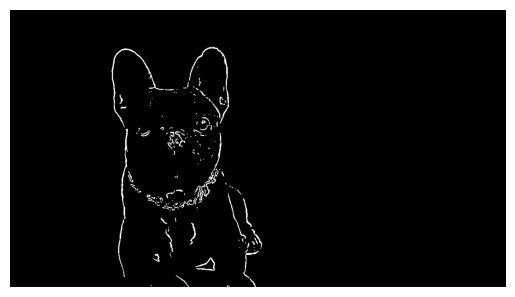

In [34]:
# dilatacao

kernel6 = (np.ones((2, 2))).astype(np.float32)
iteracao = 2

img_h, img_w = erosao.shape
ker_h, ker_w = kernel6.shape

# Definir o tamanho e tipo da saida
dilatacao = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))

for i in range(dilatacao.shape[0]):
    for j in range(dilatacao.shape[1]):
        # definindo a regiao de interesse 
        regiao = erosao[i:i+ker_h, j:j+ker_w]
        # transforma o valor do pixel no maior valor dentro do kernel 
        dilatacao[i, j] = regiao.max()


# e converte para 8bits
dilatacao = dilatacao.astype(np.uint8)

plt.axis('off')
plt.imshow(dilatacao, cmap='gray')

In [ ]:
cv2.imshow('janela', dilatacao) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

# Extração do contorno

Varredura direcional que captura apenas os pixels extremos da silhueta: borda direita (baixo→cima), topo (direita→esquerda) e borda esquerda (cima→baixo). Pontos com salto maior que o limite são descartados para evitar traços indesejados.

In [52]:
marcado = np.zeros_like(binario, dtype=bool)
caminho = []

# 1. lado direito: de baixo pra cima
for row in range(binario.shape[0] - 1, -1, -1):
    brancos = np.where(binario[row] > 0)[0]
    if len(brancos) == 0:
        continue
    col = brancos[-1]
    if not marcado[row, col]:
        caminho.append([row, col])
        marcado[row, col] = True

# 2. topo: da direita pra esquerda
for col in range(binario.shape[1] - 1, -1, -1):
    brancos = np.where(binario[:, col] > 0)[0]
    if len(brancos) == 0:
        continue
    row = brancos[0]
    if not marcado[row, col]:
        caminho.append([row, col])
        marcado[row, col] = True

# 3. lado esquerdo: de cima pra baixo
for row in range(binario.shape[0]):
    brancos = np.where(binario[row] > 0)[0]
    if len(brancos) == 0:
        continue
    col = brancos[0]
    if not marcado[row, col]:
        caminho.append([row, col])
        marcado[row, col] = True

pontos_contorno = np.array(caminho)

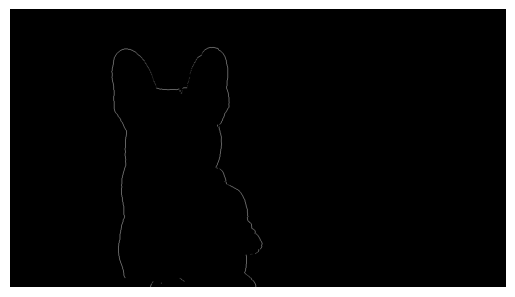

In [61]:
vis = np.zeros_like(binario)
vis[pontos_contorno[:, 0], pontos_contorno[:, 1]] = 1
plt.axis('off')
plt.imshow(vis, cmap='gray')

In [58]:
MAX_DIST = 30

pontos_filtrados = [pontos_contorno[0]]
for p in pontos_contorno[1:]:
    dist = np.sqrt(((p - pontos_filtrados[-1]) ** 2).sum())
    if dist < MAX_DIST:
        pontos_filtrados.append(p)

pontos_filtrados = np.array(pontos_filtrados)
print(f"{len(pontos_contorno)} → {len(pontos_filtrados)} pontos")

1490 → 1443 pontos


In [50]:
pontos_contorno.shape

(1490, 2)

### Salvando os pontos e o shape da imagem para a turtle desenhar

In [59]:
np.save('pontos.npy', pontos_filtrados)
np.save('img_shape.npy', np.array(binario.shape))


## caneta.py

Nó ROS2 que lê os pontos exportados pelo notebook e comanda a tartaruga.

**Inicialização:** desliga a caneta antes do timer existir, depois vai ao primeiro ponto sem riscar.

**Timer:** a cada tick, a tartaruga teletransporta para o próximo ponto da lista. A caneta é ligada no segundo tick, garantindo que o deslocamento inicial não deixe rastro.

**Conversão de coordenadas:** escala os pixels da imagem para o espaço do turtlesim (11.08 × 11.08 unidades), preservando o aspecto da imagem original e aplicando um deslocamento horizontal configurável.